In [1]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_equations import euler, rk2, rk4
from lib_fitting import lin_fit

import lib_plot

# **Initial condition**

In [2]:
y0 = np.array([np.pi/4, 0.0])
x = np.linspace(0, 30, 500)

# $\ddot{\theta}(t) = -\sin{\theta} -\gamma\dot{\theta}(t) + A\sin(\frac{2}{3}t)$



## $A=0,\ \gamma=0.3,0.6,0.9$


**************************************************
A = 0
gamma = 0.3



c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


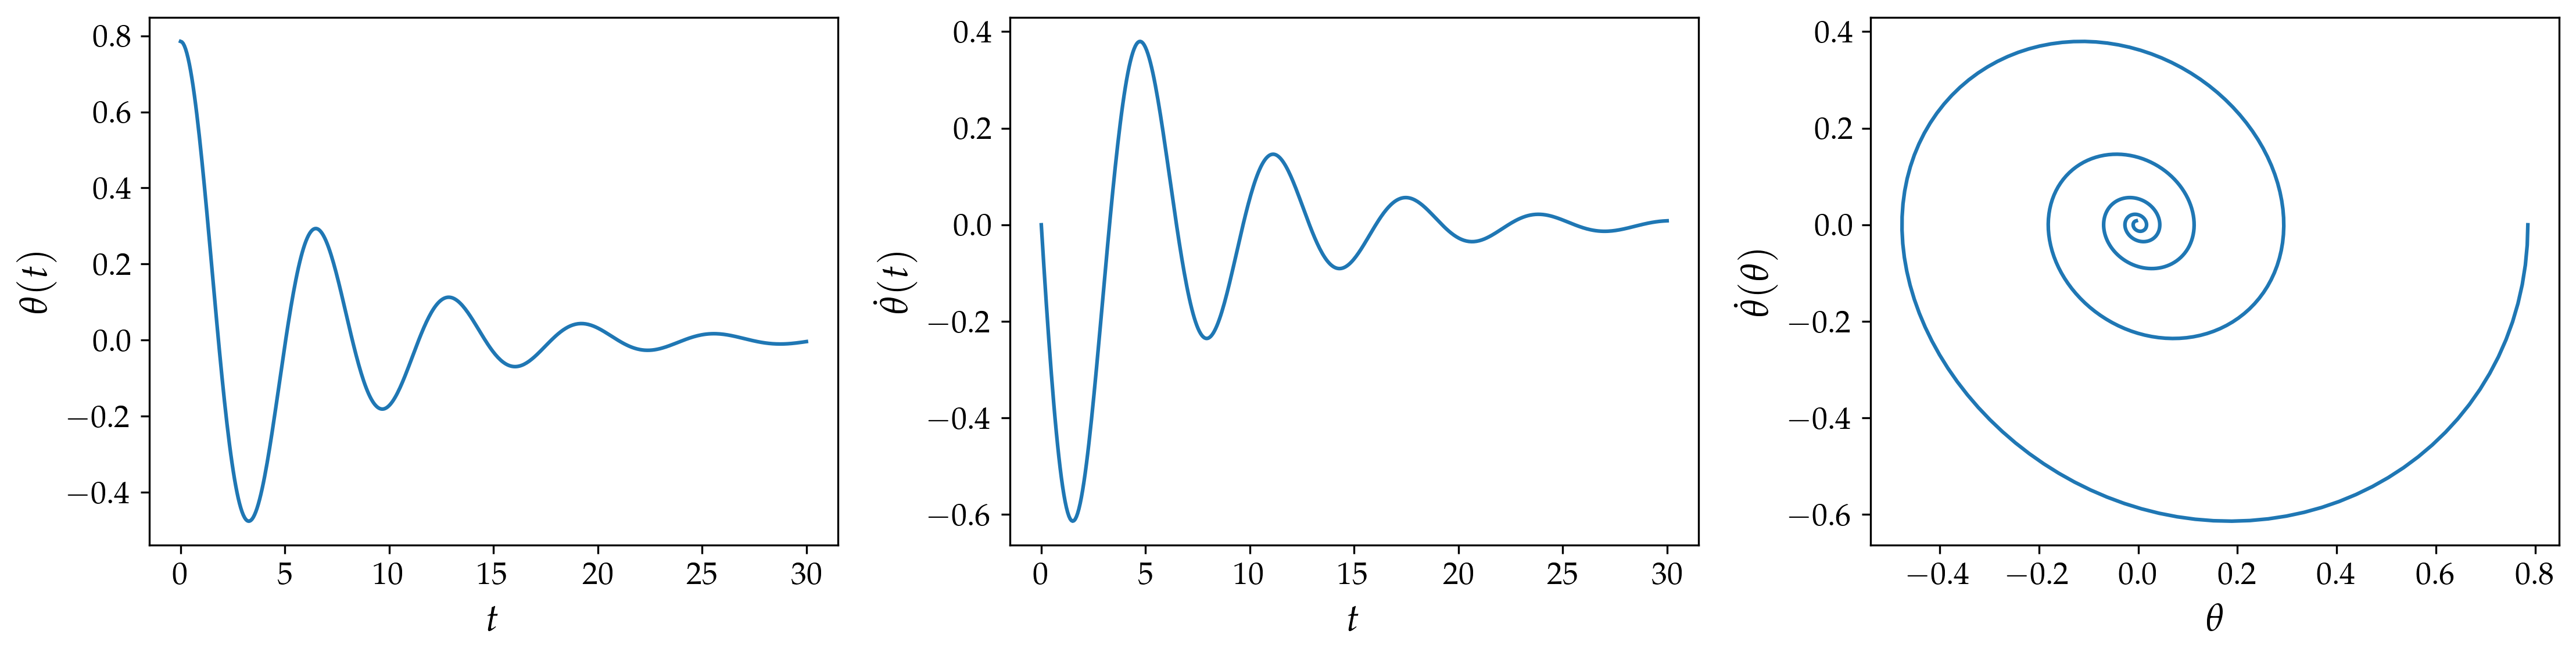


**************************************************
A = 0
gamma = 0.6



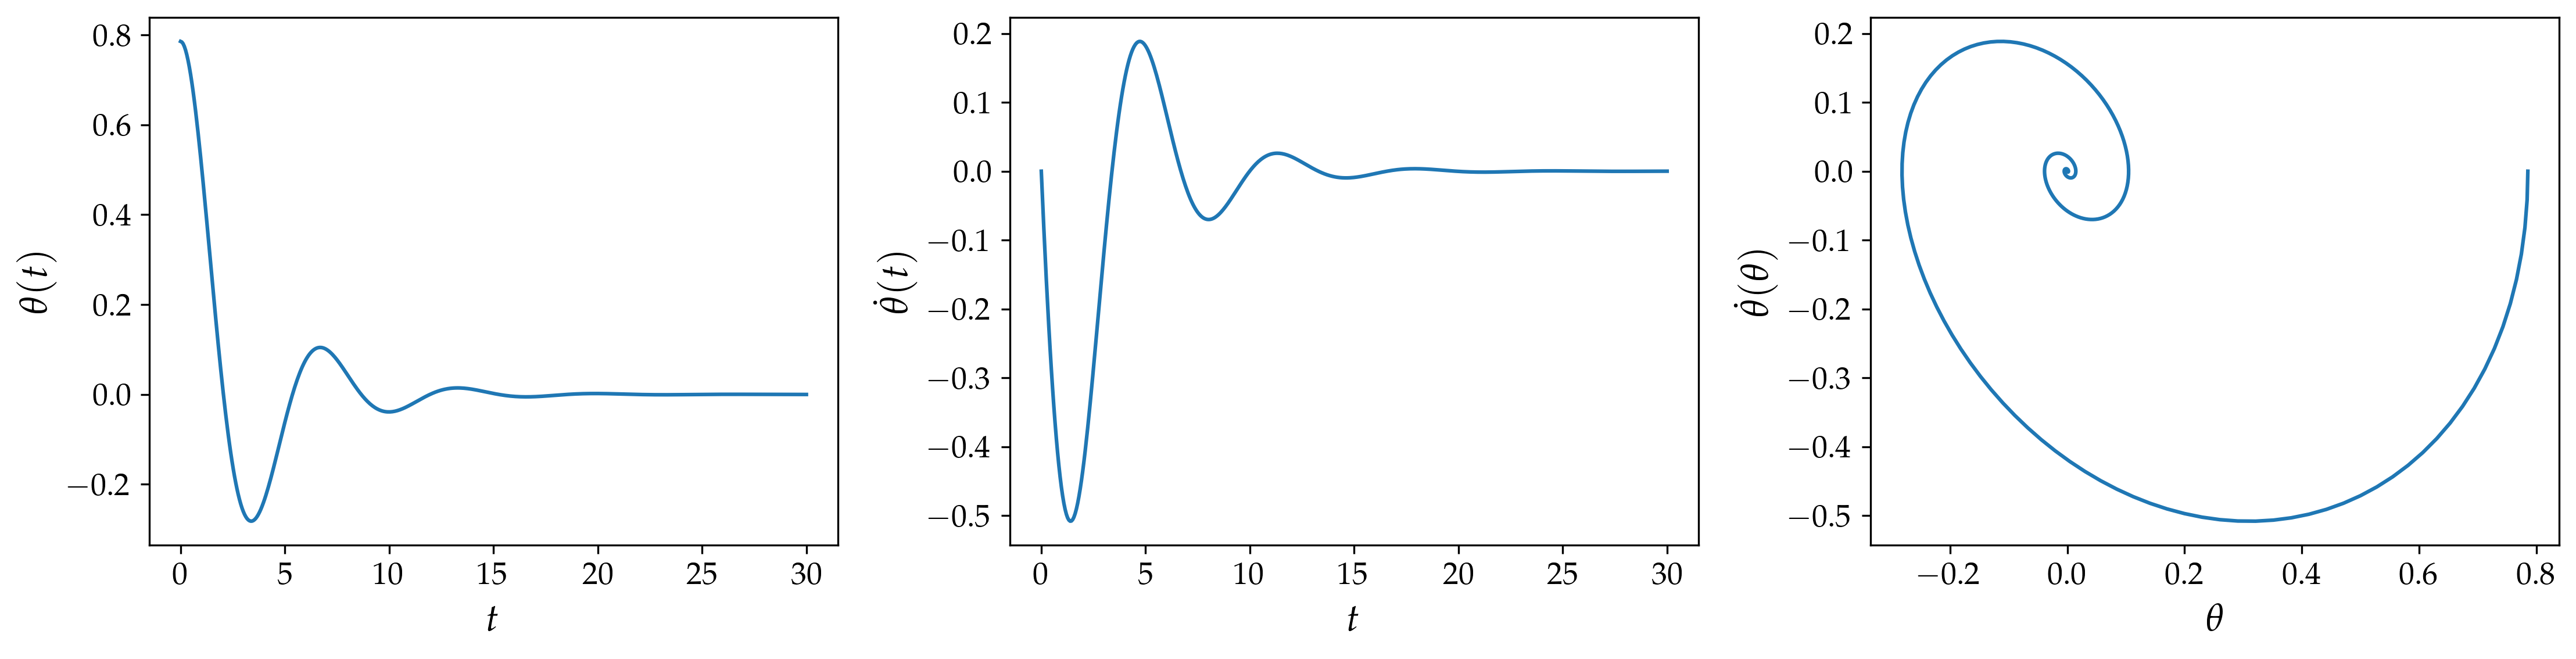


**************************************************
A = 0
gamma = 0.9



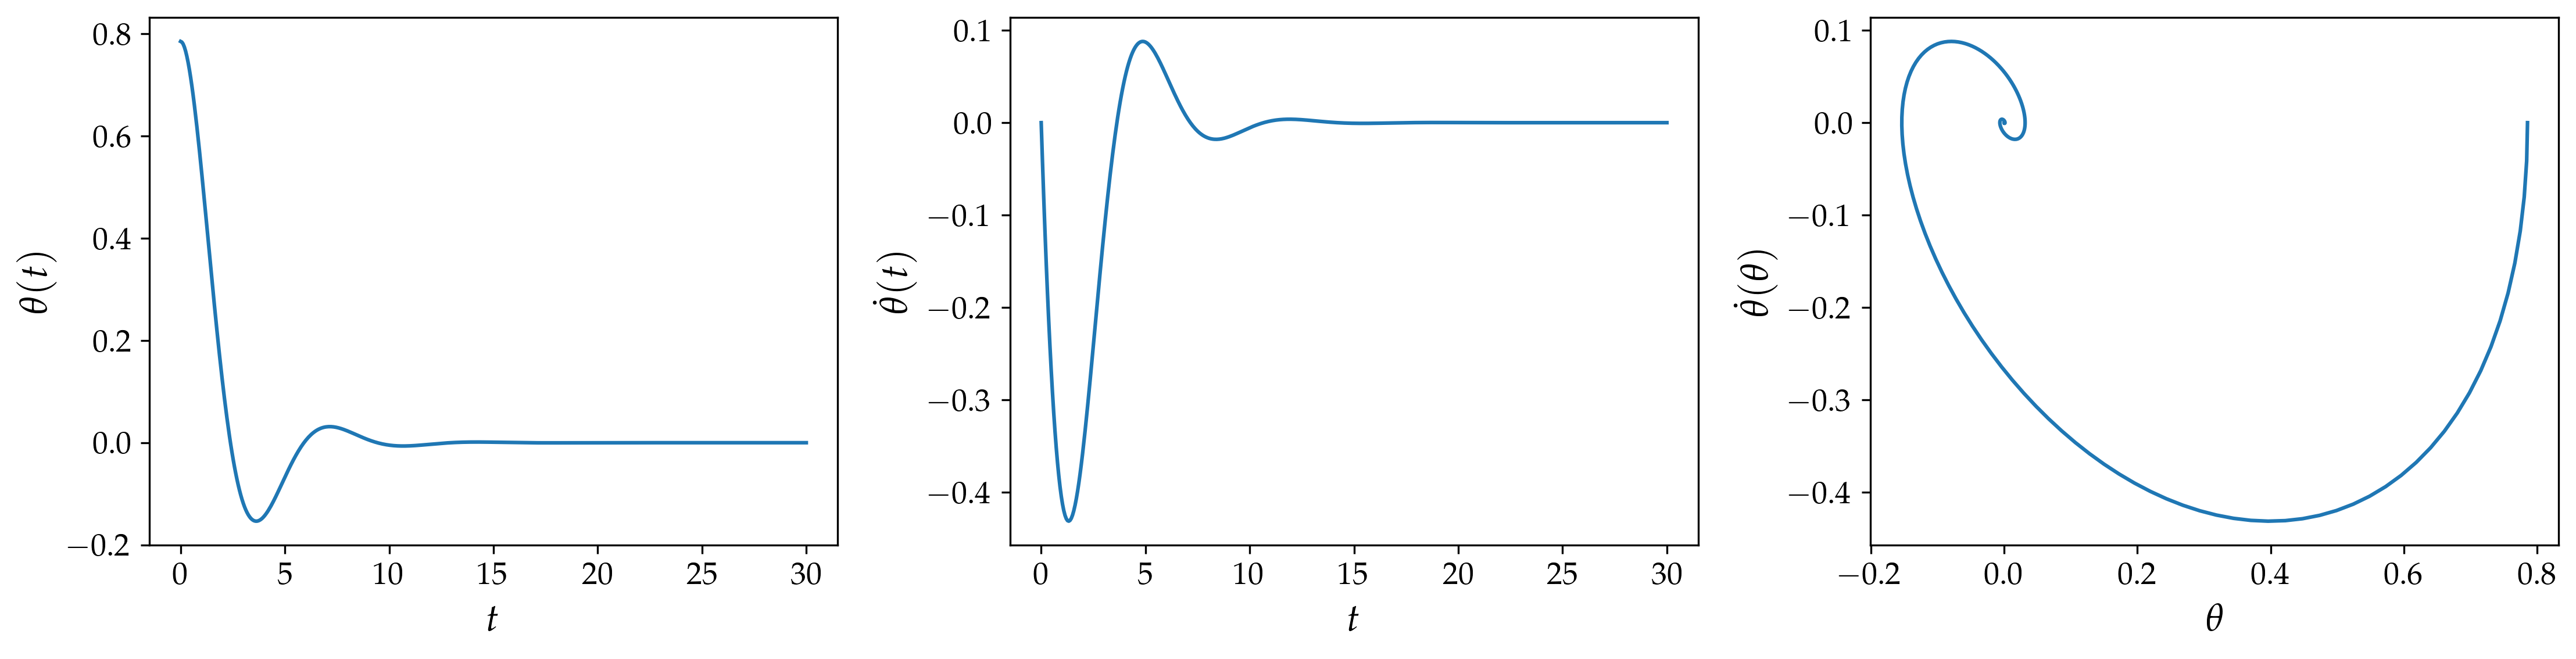

In [3]:
gamma_ls = [0.3, 0.6, 0.9]
A = 0
for gamma in gamma_ls:
    print()
    print('*'*50)
    print(f'A = {A}') 
    print(f'gamma = {gamma}') 
    print()
    def damp_osc(t, u):
        u0, u1 = u
        du0 = u1
        du1 = -np.sin(u0) -gamma*u1 + A*np.sin(2/3*t)
        return np.array([du0, du1])


    sols = rk4(damp_osc, y0, x)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(x, sols[:, 0])
    ax[1].plot(x, sols[:, 1])
    ax[2].plot(sols[:, 0], sols[:, 1])
    ax[0].set_xlabel(r'$t$')
    ax[0].set_ylabel(r'$\theta(t)$')
    ax[1].set_xlabel(r'$t$')
    ax[1].set_ylabel(r'$\dot \theta(t)$')
    ax[2].set_xlabel(r'$\theta$')
    ax[2].set_ylabel(r'$\dot \theta(\theta)$')

    plt.tight_layout()
    name = f'A{A}_g{str(gamma).replace(".", "")}'
    plt.savefig('plots_damp/'+name)
    plt.show()


## $A=0.5, 1.5,\ \gamma=0.3,0.9$


**************************************************
A = 0.5
gamma = 0.3



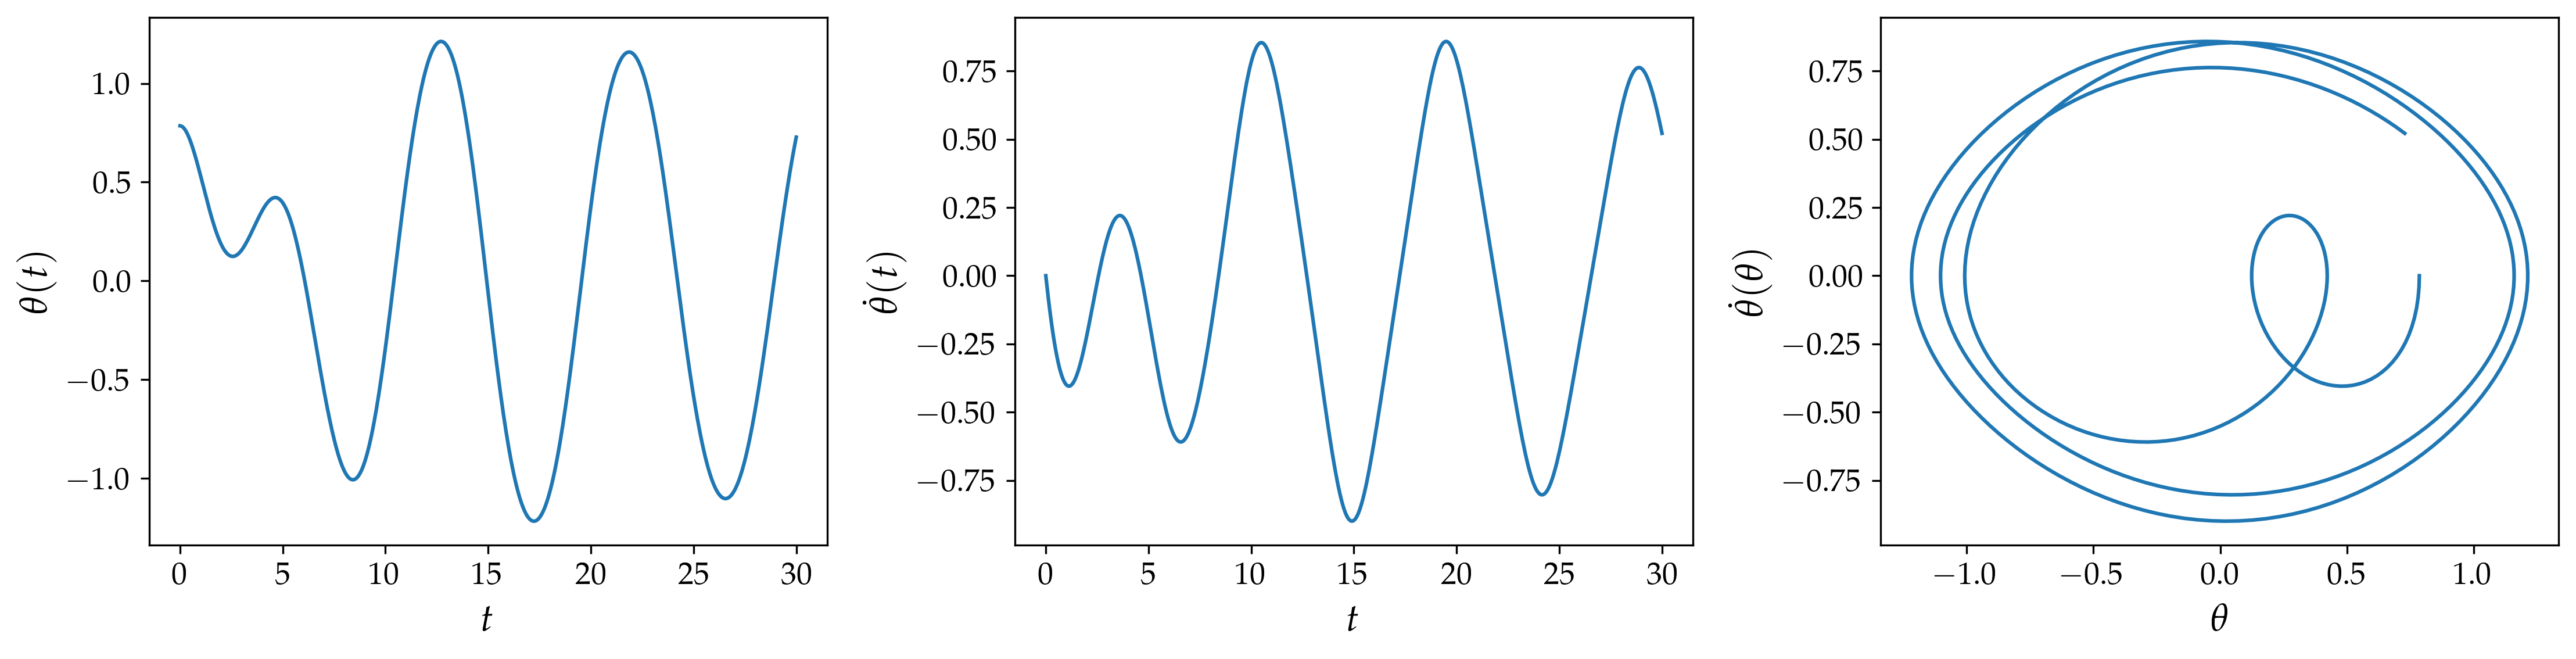

A = 0.5
gamma = 0.9



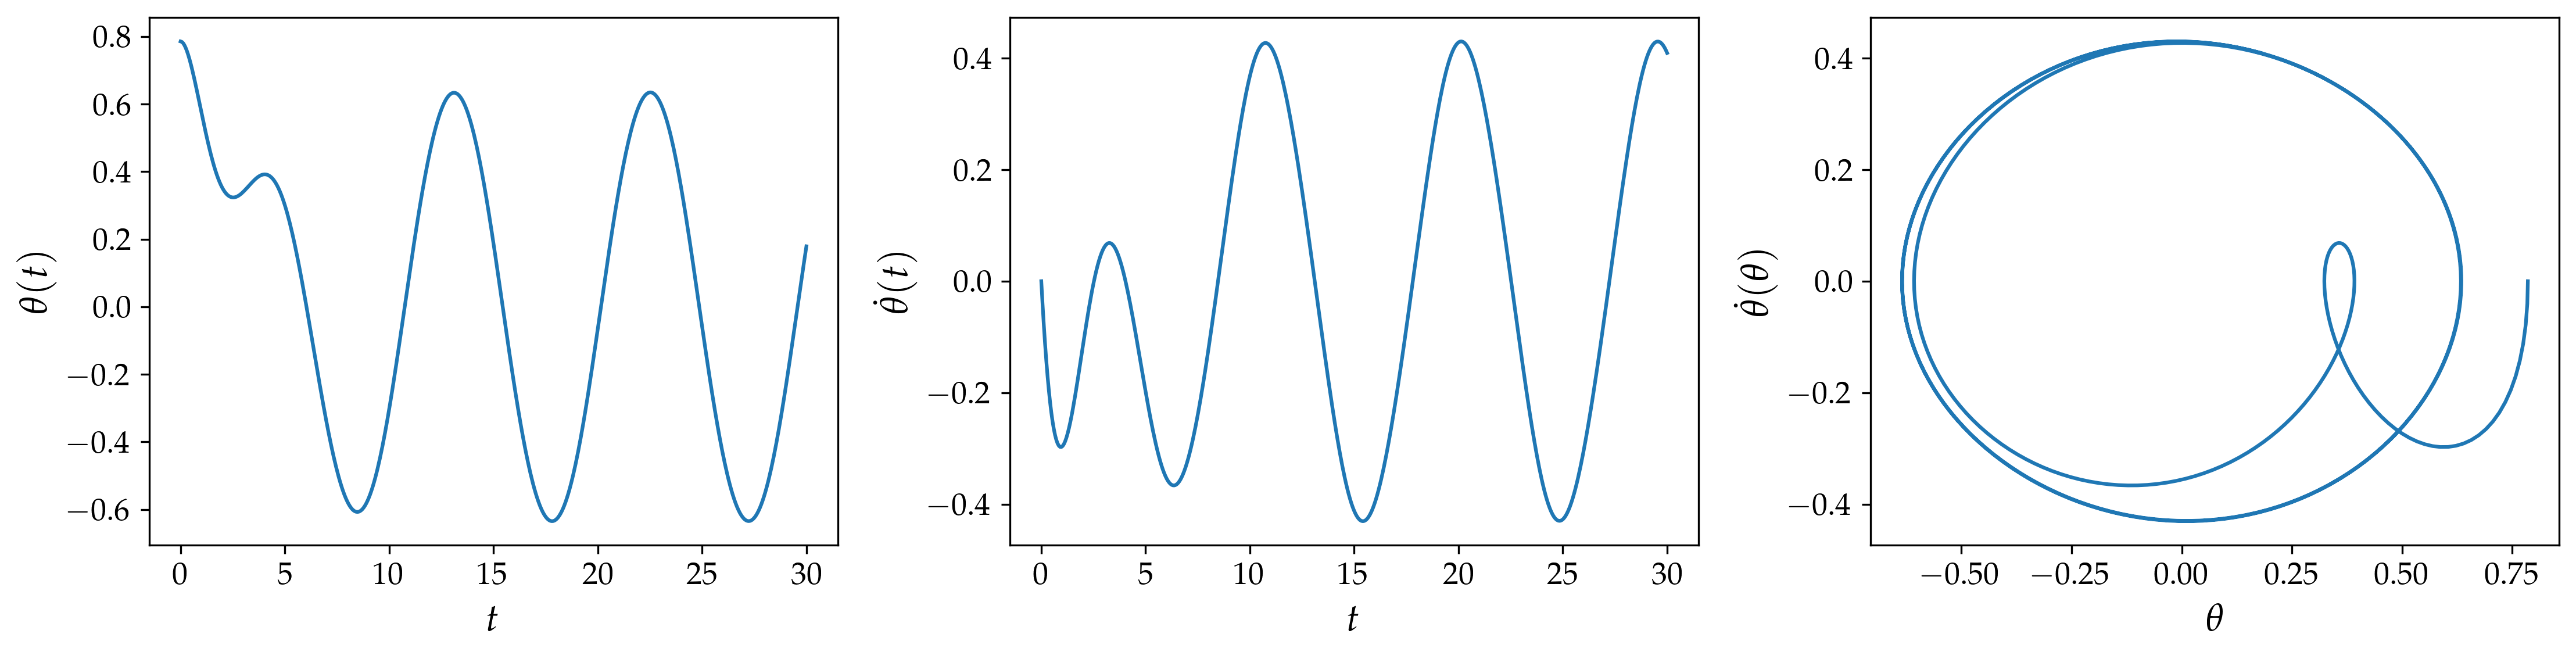


**************************************************
A = 1.5
gamma = 0.3



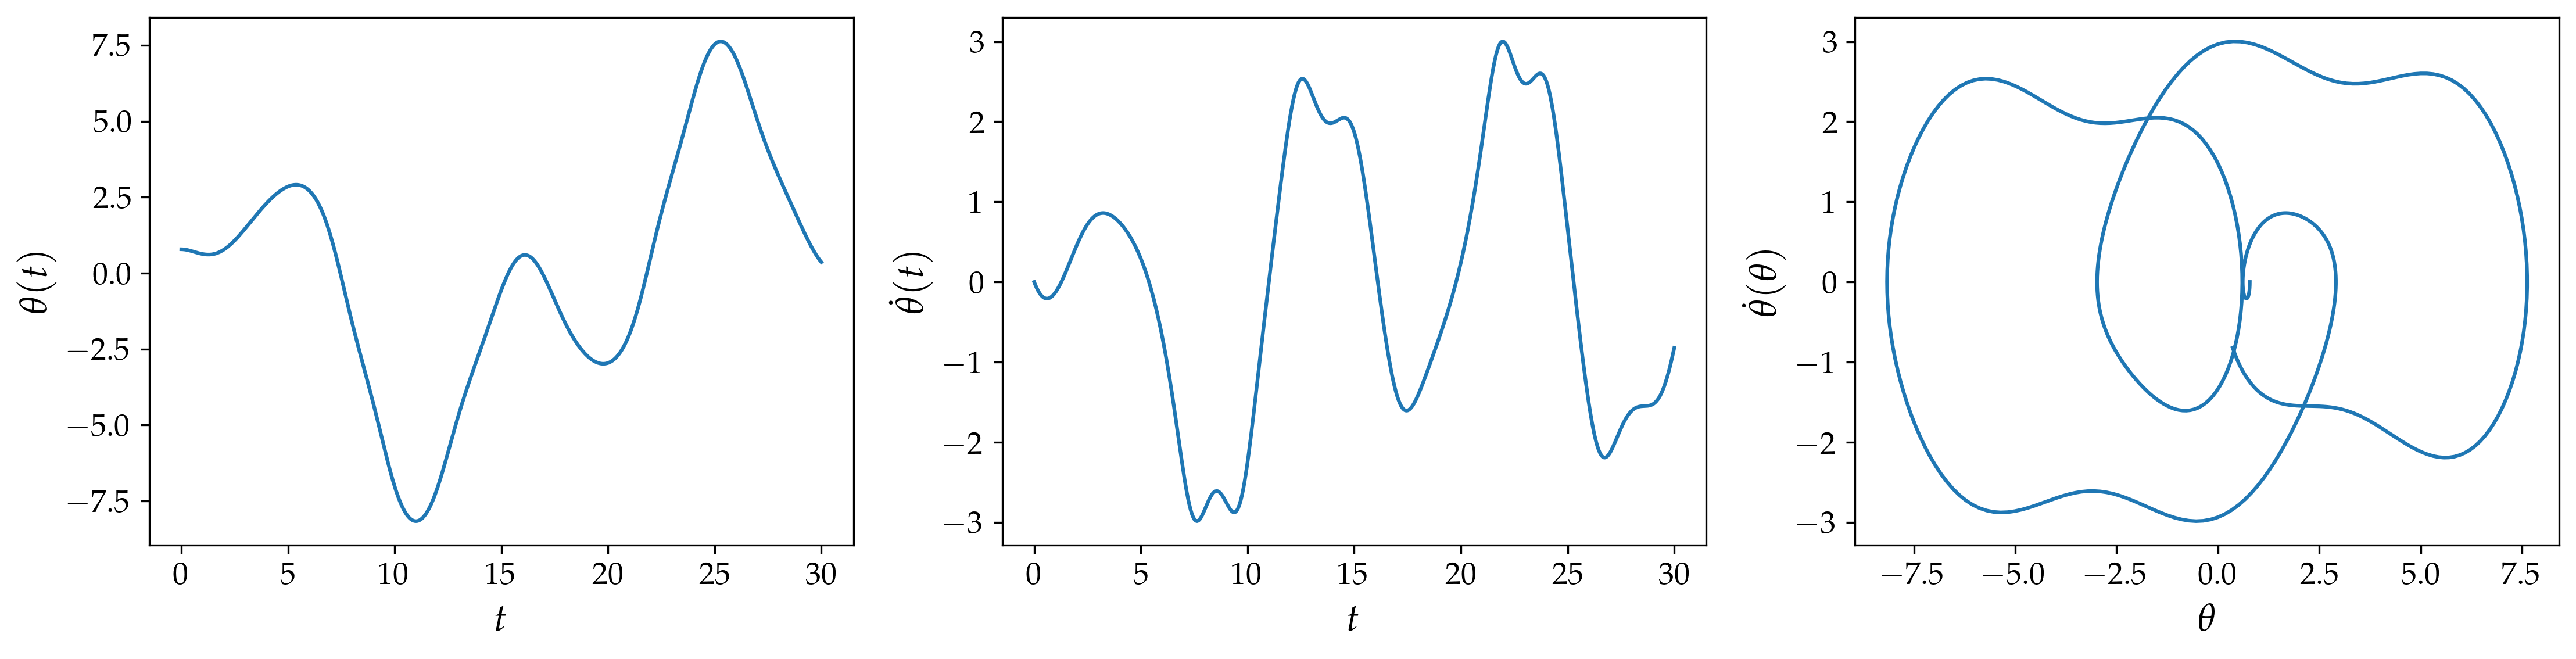

A = 1.5
gamma = 0.9



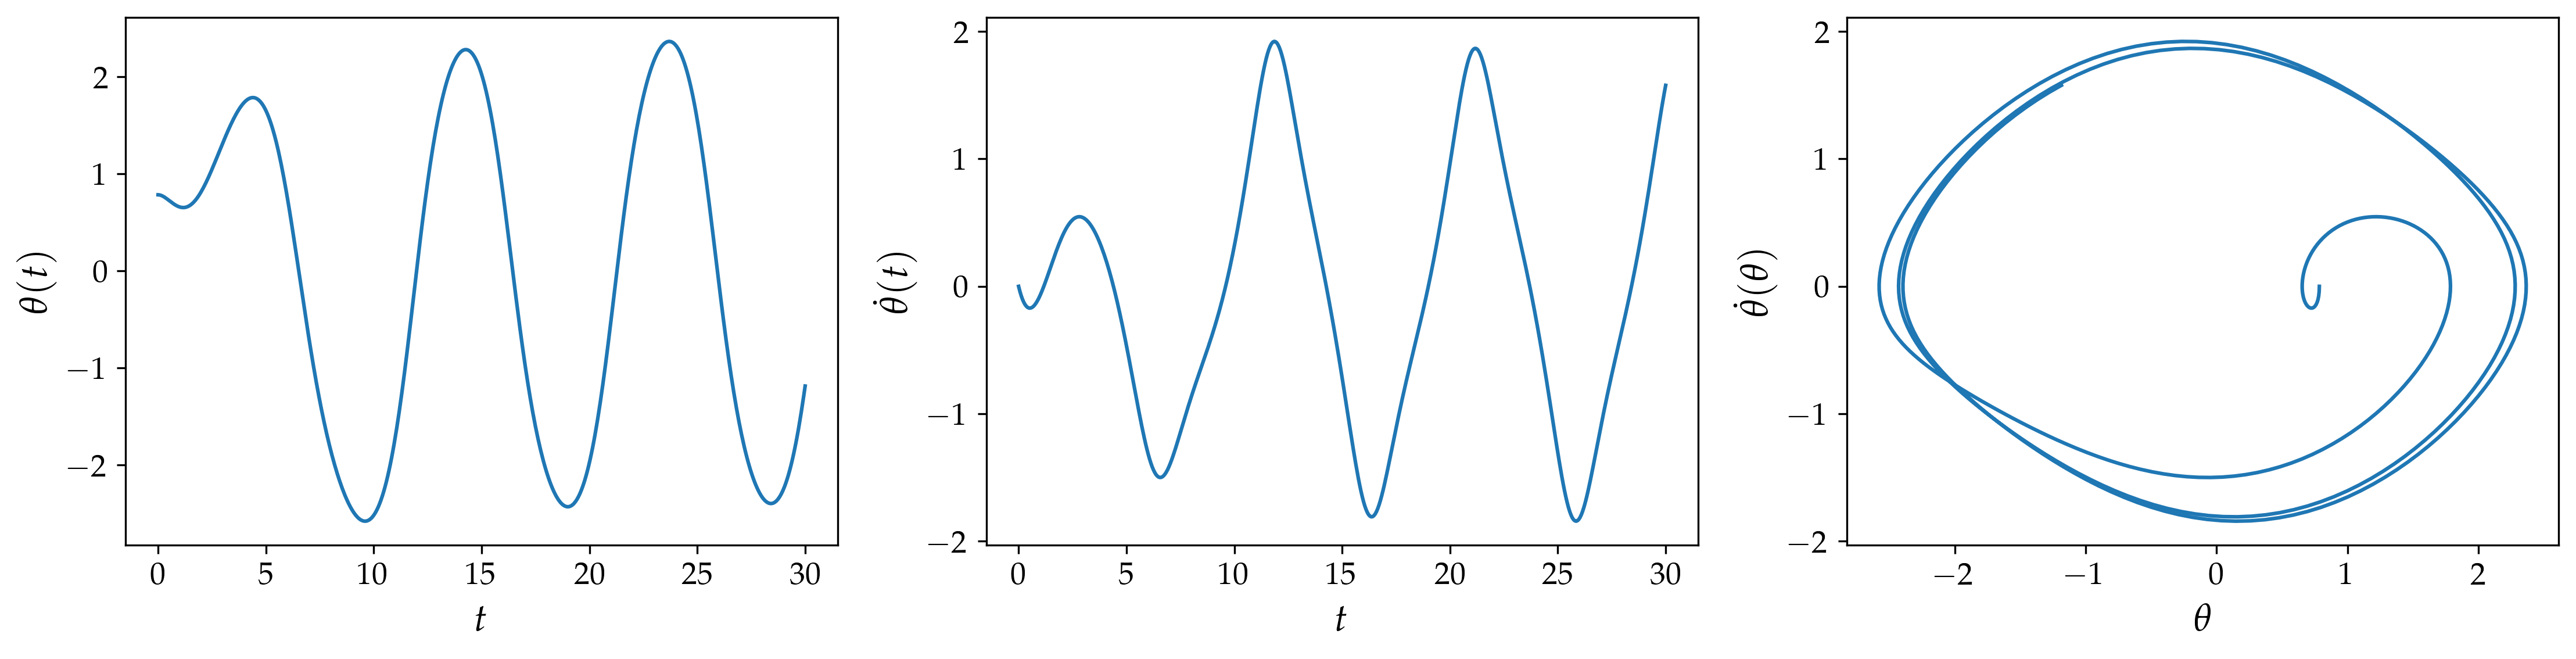

In [4]:
gamma_ls = [0.3, 0.9]
A_ls = [0.5, 1.5]
for A in A_ls:
    print()
    print('*'*50)
    for gamma in gamma_ls:
        print(f'A = {A}') 
        print(f'gamma = {gamma}') 
        print()
        def damp_osc(t, u):
            u0, u1 = u
            du0 = u1
            du1 = -np.sin(u0) -gamma*u1 + A*np.sin(2/3*t)
            return np.array([du0, du1])

        sols = rk4(damp_osc, y0, x)

        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        ax[0].plot(x, sols[:, 0])
        ax[1].plot(x, sols[:, 1])
        ax[2].plot(sols[:, 0], sols[:, 1])
        ax[0].set_xlabel(r'$t$')
        ax[0].set_ylabel(r'$\theta(t)$')
        ax[1].set_xlabel(r'$t$')
        ax[1].set_ylabel(r'$\dot \theta(t)$')
        ax[2].set_xlabel(r'$\theta$')
        ax[2].set_ylabel(r'$\dot \theta(\theta)$')

        plt.tight_layout()
        name = f'A{str(A).replace(".", "")}_g{str(gamma).replace(".", "")}'
        plt.savefig('plots_damp/'+name)
        plt.show()


# **Demostrate the convergence of algorithm**

A = 0
gamma = 0.3



C:\Users\Marco\AppData\Local\Temp\ipykernel_23316\2166664242.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  yerr = np.array(ysols_ls, dtype=float) - y_true


dof = 18

a = 4.30e+00 +/- 4.065e-01
b = -1.85e+00 +/- 6.112e-01

Chi2 = 0.18
p-val = 1.00


c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


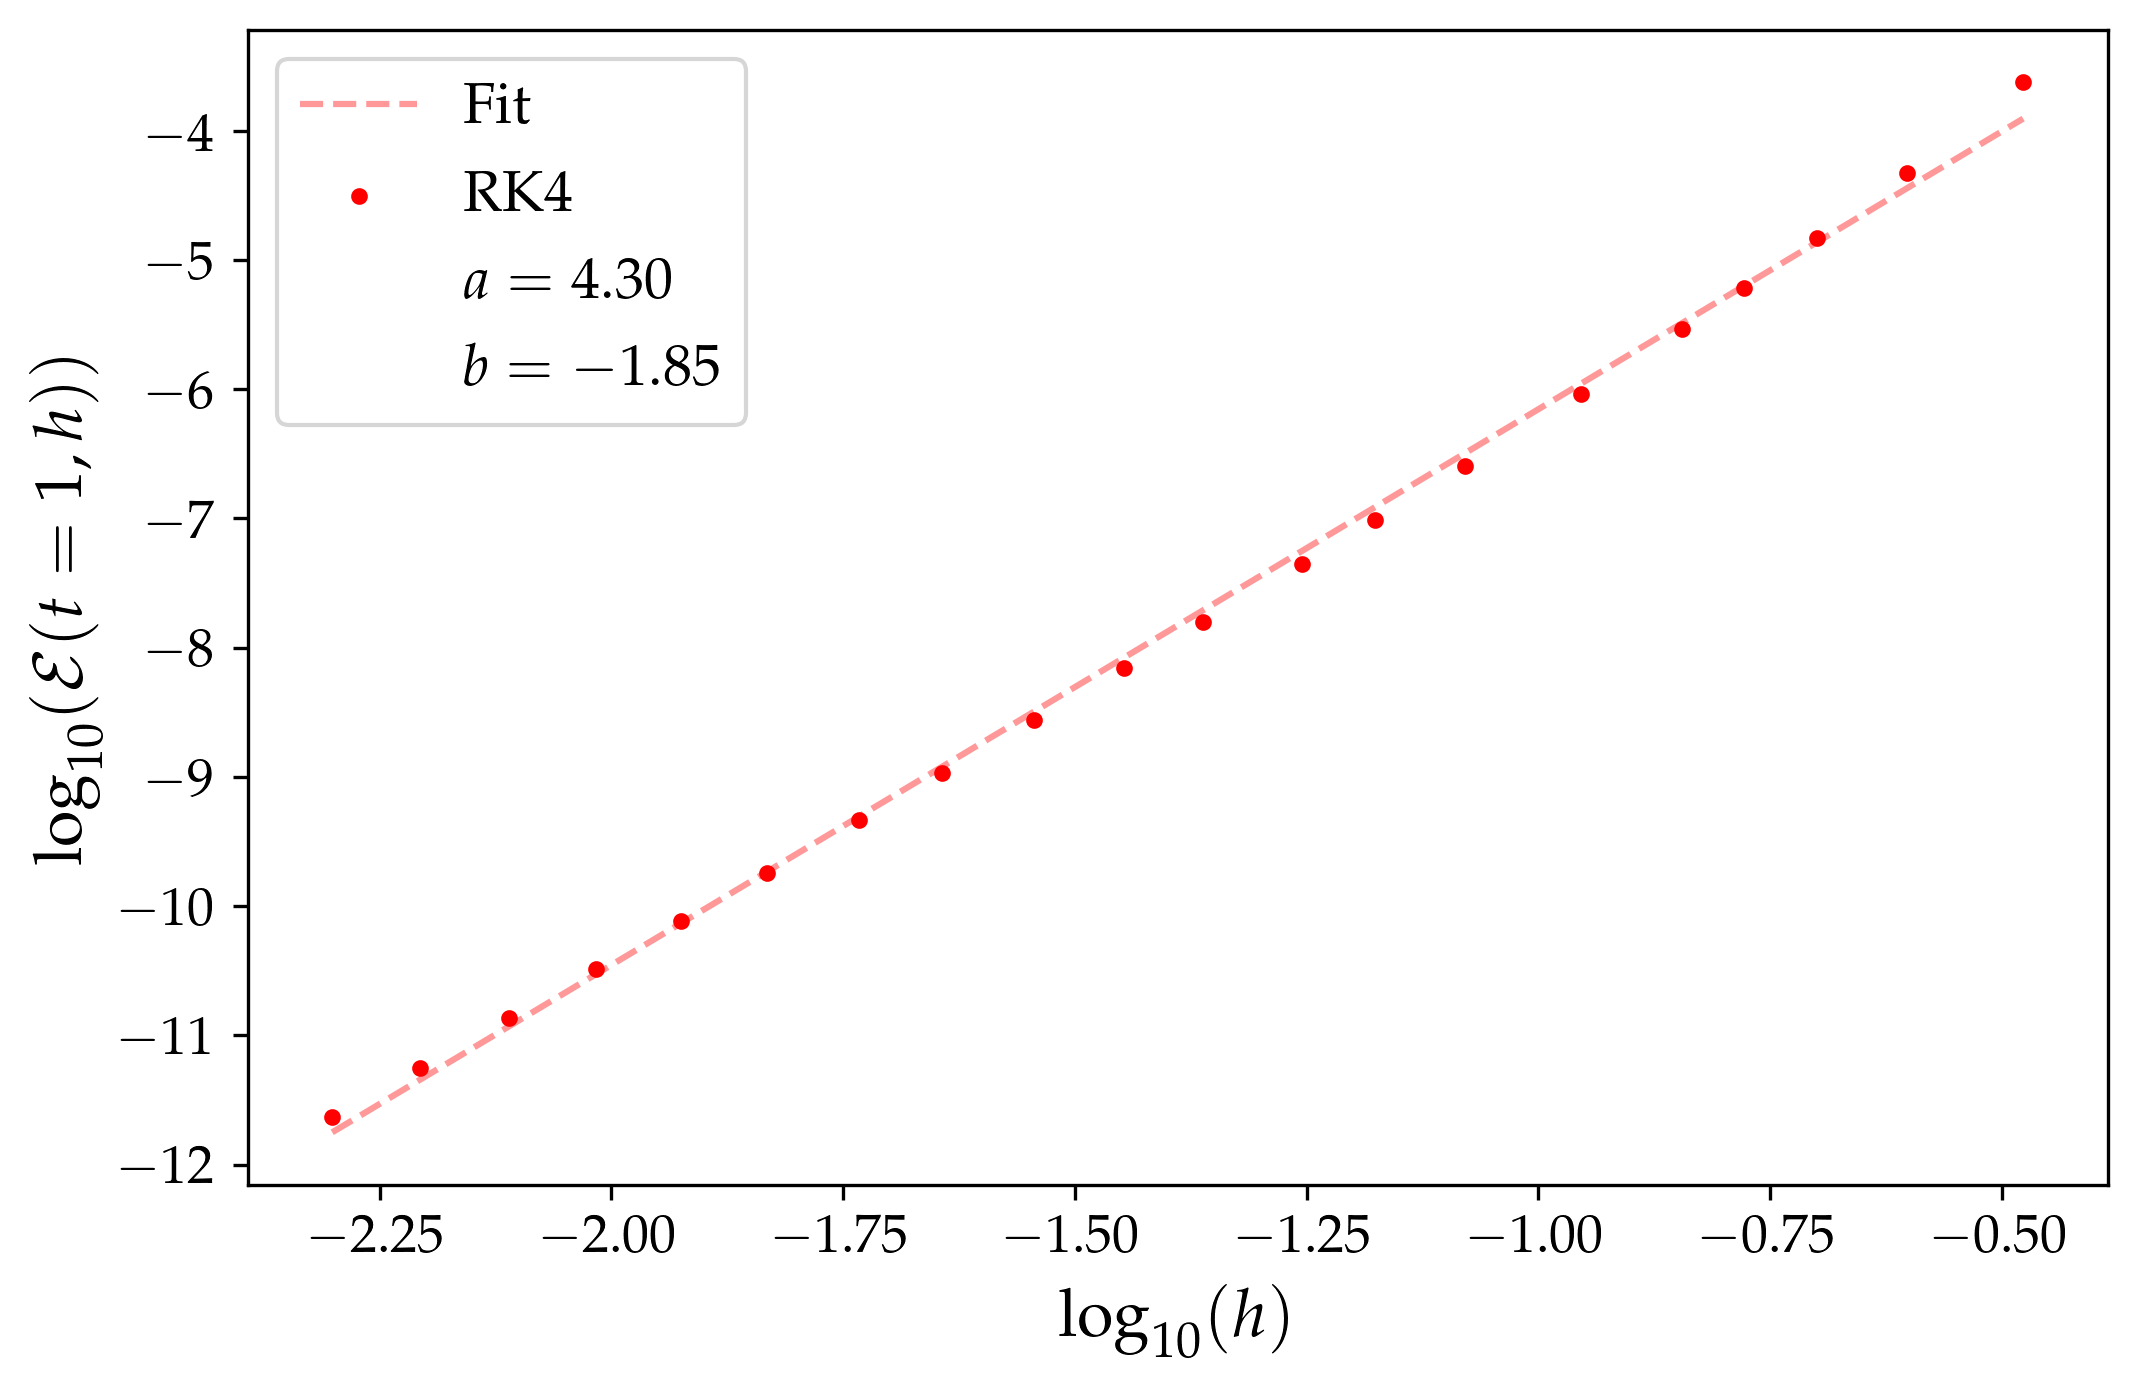

([np.float64(4.301595821202778), np.float64(-1.8528690186523327)],
 array([[0.1652404 , 0.23123127],
        [0.23123127, 0.37357643]]),
 np.float64(0.18411195747873038),
 np.float64(0.9999999999999988))

In [5]:
# my choice is to use the case of A=0, g=0.3, a regular one
A = 0
gamma = 0.3

print(f'A = {A}') 
print(f'gamma = {gamma}') 
print()
def damp_osc(t, u):
    u0, u1 = u
    du0 = u1
    du1 = -np.sin(u0) -gamma*u1 + A*np.sin(2/3*t)
    return np.array([du0, du1])


t_fix = 1
h_min, h_max = [5e-3, 0.3]
n_hs = 20   # number of h, step of the interval, chosen for the logspacing

n_pts = np.logspace(np.log10(t_fix / h_min), np.log10(t_fix /h_max), n_hs, dtype=int)
x_mini_span = [np.linspace(0, t_fix, n) for n in n_pts]
h_span =  t_fix / n_pts

# analytic sol
sols_num = rk4(damp_osc, y0, np.linspace(0, t_fix, 1000))
y_true = sols_num[:, 0][-1]

ysols_ls = []
for x_mini in x_mini_span:
    y_sols = rk4(damp_osc, y0, x_mini)
    ysols_ls.append(y_sols[:, 0][-1])

yerr = np.array(ysols_ls, dtype=float) - y_true

x, y = (np.log10(h_span), np.log10(yerr))
lin_fit(x, y, labels=[r'$\log_{10}(h)$', r'$\log_{10}(\mathcal E(t=1, h))$'],
        name_points='RK4', save_name='plots/_fit_rk4')
    